In [1]:
import pandas as pd
import random
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
uploaded = files.upload()

Saving ai_assistant_usage_student_life.csv to ai_assistant_usage_student_life.csv


In [3]:
df=pd.read_csv('/content/ai_assistant_usage_student_life.csv')

In [4]:
df

,SessionID,StudentLevel,Discipline,SessionDate,SessionLengthMin,TotalPrompts,TaskType,AI_AssistanceLevel,FinalOutcome,UsedAgain,SatisfactionRating
0,SESSION00001,Undergraduate,Computer Science,2024-11-03,31.20,11,Studying,2,Assignment Completed,True,1.0
1,SESSION00002,Undergraduate,Psychology,2024-08-25,13.09,6,Studying,3,Assignment Completed,True,2.0
2,SESSION00003,Undergraduate,Business,2025-01-12,19.22,5,Coding,3,Assignment Completed,True,3.3
3,SESSION00004,Undergraduate,Computer Science,2025-05-06,3.70,1,Coding,3,Assignment Completed,True,3.5
4,SESSION00005,Undergraduate,Psychology,2025-03-18,28.12,9,Writing,3,Assignment Completed,True,2.9
...,...,...,...,...,...,...,...,...,...,...,...
9995,SESSION09996,Undergraduate,Psychology,2024-07-20,28.41,5,Studying,3,Assignment Completed,True,4.2
9996,SESSION09997,High School,Business,2024-11-11,13.98,6,Writing,5,Assignment Completed,True,5.0
9997,SESSION09998,Undergraduate,Biology,2024-09-11,10.78,2,Studying,3,Idea Drafted,True,3.5
9998,SESSION09999,Undergraduate,Business,2024-10-27,30.88,7,Writing,3,Assignment Completed,False,4.3


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   SessionID           10000 non-null  object 
 1   StudentLevel        10000 non-null  object 
 2   Discipline          10000 non-null  object 
 3   SessionDate         10000 non-null  object 
 4   SessionLengthMin    10000 non-null  float64
 5   TotalPrompts        10000 non-null  int64  
 6   TaskType            10000 non-null  object 
 7   AI_AssistanceLevel  10000 non-null  int64  
 8   FinalOutcome        10000 non-null  object 
 9   UsedAgain           10000 non-null  bool   
 10  SatisfactionRating  10000 non-null  float64
dtypes: bool(1), float64(2), int64(2), object(6)
memory usage: 791.1+ KB


In [6]:
#عدد الصفوف والاعمدة
df.shape

(10000, 11)

##🟡 **Corrupting clean dataset**

##🎰 إضافة قيم متكررة

In [7]:
# اضافة قيم مكررة 1
dublicat=df.iloc[0:50]
df=pd.concat([df,dublicat],ignore_index=True)
df.duplicated().sum()

np.int64(50)

##📊🪄تغير بعض انواع الاعمدة


In [8]:
df['SatisfactionRating'].dtype

dtype('float64')

In [9]:
df['SatisfactionRating']=df['SatisfactionRating'].astype(str)

In [10]:
df['SatisfactionRating'].dtype

dtype('O')

 ## 📲إدخل قيم شاذة في بعض الاعمدة

In [11]:
df.loc[0,'AI_AssistanceLevel']=99

In [12]:
df.loc[1,'AI_AssistanceLevel']=1000000

In [13]:
df.loc[2,'AI_AssistanceLevel']=-785

In [14]:
df.loc[3,'AI_AssistanceLevel']=42

In [15]:
df.loc[4,'AI_AssistanceLevel']=-978

In [16]:
df.loc[5,'AI_AssistanceLevel']=889774

In [17]:
df['AI_AssistanceLevel'].min()

-978

In [18]:
df['AI_AssistanceLevel'].max()

1000000

In [19]:
df['AI_AssistanceLevel'].unique()

array([     99, 1000000,    -785,      42,    -978,  889774,       3,
             5,       2,       4,       1])

##📊إدخال بيانات غير متناسقة


In [67]:
coding_variants=['CODING','cod','ccoding']
coding_rows=df[df['TaskType'].str.lower()=='coding']
sampl=random.sample(list(coding_rows.index),min(100,len(coding_rows)))
for idx in sampl:
     df.at[idx,'TaskType']=random.choice(coding_variants)

In [68]:
df['TaskType'].unique()
#التأكد من إدخال البيانات اللغير ممتنناسقة بشكل صحيح

array(['studying', 'coding', 'writing', 'brainstorming', 'homework help',
       'research', 'CODING', 'cod', 'ccoding', 'Unknown'], dtype=object)

## إضافة قيم ناقصة في البيانات📑

In [22]:


# الأعمدة التي سيتم إدخال قيم مفقودة فيها
columns_to_nan = ['StudentLevel','Discipline','TaskType','UsedAgain','SessionLengthMin','TotalPrompts',       'SatisfactionRating'
]

# إدخال NaN في 10 خلايا عشوائية ضمن الأعمدة المحددة
for _ in range(10):
    index = random.choice(df.index)
    column = random.choice(columns_to_nan)
    df.at[index, column] = None

/tmp/ipython-input-337020853.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.at[index, column] = None


In [23]:
df.isnull().sum()

,0
SessionID,0
StudentLevel,1
Discipline,1
SessionDate,0
SessionLengthMin,2
TotalPrompts,1
TaskType,1
AI_AssistanceLevel,0
FinalOutcome,0
UsedAgain,4


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10050 entries, 0 to 10049
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   SessionID           10050 non-null  object 
 1   StudentLevel        10049 non-null  object 
 2   Discipline          10049 non-null  object 
 3   SessionDate         10050 non-null  object 
 4   SessionLengthMin    10048 non-null  float64
 5   TotalPrompts        10049 non-null  float64
 6   TaskType            10049 non-null  object 
 7   AI_AssistanceLevel  10050 non-null  int64  
 8   FinalOutcome        10050 non-null  object 
 9   UsedAgain           10046 non-null  object 
 10  SatisfactionRating  10050 non-null  object 
dtypes: float64(2), int64(1), object(8)
memory usage: 863.8+ KB


##**📊🧼🫧  **Data Preparation****

# توحيد القيم🎰



In [25]:
# 'TaskType'توحيد القيم في عمود
df['TaskType']=df['TaskType'].replace({'CODING':'coding',
                                       'cod':'coding',
                                       'ccoding':'coding'}).str.lower()


In [26]:
df['TaskType'].unique()

array(['studying', 'coding', 'writing', 'brainstorming', 'homework help',
       'research', None], dtype=object)

#🗑️حذف القيم الشاذة

In [27]:
print(df['AI_AssistanceLevel'].value_counts())

AI_AssistanceLevel
 4          3459
 3          3377
 5          1599
 2          1367
 1           242
 99            1
 1000000       1
-785           1
 889774        1
 42            1
-978           1
Name: count, dtype: int64


 ✂️اغلب القيم تتمركز من   1إلى 5  مما يوضح ان القيم الباقية هي قيم شاذة  و سوف نقوم بقتصاص القيم المطلوب وحذف القيم الشاذة

In [28]:
df['AI_AssistanceLevel']=df['AI_AssistanceLevel'].clip(lower=1,upper=5)

In [29]:
print(df['AI_AssistanceLevel'].value_counts())

AI_AssistanceLevel
4    3459
3    3377
5    1603
2    1367
1     244
Name: count, dtype: int64


#تحويل نوع العمود من نص إلى ارقام🎯

In [30]:
df['SatisfactionRating']=pd.to_numeric(df['SatisfactionRating'],errors='coerce')
df['SatisfactionRating'].unique()

array([1. , 2. , 3.3, 3.5, 2.9, 5. , 1.9, 3.9, 1.4, 4.9, 3.7, 2.8, 1.2,
       4.4, 3.1, 3.6, 4.3, 3.2, 4. , 3.4, 2.5, 2.4, 2.6, 1.6, 2.2, 1.7,
       4.6, 4.8, 2.3, 4.2, 4.5, 2.7, 3.8, 3. , 1.8, 1.5, 4.1, 4.7, 2.1,
       1.3, 1.1])

#حذف القيم المتكررة🎰

In [31]:
# عدد الصفوف المكررة
duplicate_rows = df.duplicated().sum()
print(f"عدد الصفوف المكررة: {duplicate_rows}")

عدد الصفوف المكررة: 45


In [32]:
# حذف الصفوف المكررة
df.drop_duplicates(inplace=True)

#معالجة القيم الناقصة🪄

In [33]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print("الأعمدة اللي فيها قيم ناقصة:\n", missing)

الأعمدة اللي فيها قيم ناقصة:
 StudentLevel        1
Discipline          1
SessionLengthMin    2
TotalPrompts        1
TaskType            1
UsedAgain           4
dtype: int64


In [34]:
# تعويض القيم النصية الناقصة بكلمة "Unknown"
df['StudentLevel'] = df['StudentLevel'].fillna('Unknown')
df['Discipline'] = df['Discipline'].fillna('Unknown')
df['TaskType'] = df['TaskType'].fillna('Unknown')
df['UsedAgain'] = df['UsedAgain'].fillna('Unknown')

# تعويض القيم الرقمية الناقصة بمتوسط العمود
df['SessionLengthMin'] = df['SessionLengthMin'].fillna(df['SessionLengthMin'].mean())
df['TotalPrompts'] = df['TotalPrompts'].fillna(df['TotalPrompts'].mean())
df['SatisfactionRating'] = df['SatisfactionRating'].fillna(df['SatisfactionRating'].mean())


In [35]:
print("عدد القيم الناقصة بعد التنظيف:\n")
print(df.isnull().sum())

عدد القيم الناقصة بعد التنظيف:

SessionID             0
StudentLevel          0
Discipline            0
SessionDate           0
SessionLengthMin      0
TotalPrompts          0
TaskType              0
AI_AssistanceLevel    0
FinalOutcome          0
UsedAgain             0
SatisfactionRating    0
dtype: int64


In [36]:
#هنا راح نتجاهل اكل شي ونركز على true and false
used_again_clean = df[df['UsedAgain'].isin([True, False])]['UsedAgain']

# حساب النسب بعد التنظيف
used_again_counts = used_again_clean.value_counts()



#📈✏️ **Statistical and digital analysis**

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10005 entries, 0 to 10004
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   SessionID           10005 non-null  object 
 1   StudentLevel        10005 non-null  object 
 2   Discipline          10005 non-null  object 
 3   SessionDate         10005 non-null  object 
 4   SessionLengthMin    10005 non-null  float64
 5   TotalPrompts        10005 non-null  float64
 6   TaskType            10005 non-null  object 
 7   AI_AssistanceLevel  10005 non-null  int64  
 8   FinalOutcome        10005 non-null  object 
 9   UsedAgain           10005 non-null  object 
 10  SatisfactionRating  10005 non-null  float64
dtypes: float64(3), int64(1), object(7)
memory usage: 938.0+ KB


In [38]:
# انواع المهام المستخدمة في الذكاء الاصطناعي
df["TaskType"].unique()

array(['studying', 'coding', 'writing', 'brainstorming', 'homework help',
       'research', 'Unknown'], dtype=object)

In [39]:
# عدد الطلاب في كل مستوى
df["StudentLevel"].value_counts()

,count
StudentLevel,
Undergraduate,5982
High School,2027
Graduate,1995
Unknown,1


In [40]:
# اقل مدة جلسة
df["SessionLengthMin"].min()

0.03

In [41]:
# اعلى مدة جلسة
df["SessionLengthMin"].max()

110.81

In [42]:
# متوسط مدة الجلسة
df["SessionLengthMin"].mean()

np.float64(19.839612116365092)

In [43]:
# اقل تقييم للرضا
df["SatisfactionRating"].min()

1.0

In [44]:
# اعلى تقييم للرضا
df["SatisfactionRating"].max()

5.0

In [45]:
# متوسط تقييم الرضا
df["SatisfactionRating"].mean()

np.float64(3.4173413293353323)

In [46]:
# متوسط عدد ال prompts لكل نوع مهمه
df.groupby('TaskType')['TotalPrompts'].mean()

,TotalPrompts
TaskType,
Unknown,4.000000
brainstorming,6.271008
coding,5.527692
homework help,5.694032
research,5.714286
studying,5.532092
writing,5.536428


In [47]:
df['SessionLengthMin'].value_counts()

,count
SessionLengthMin,
10.57,12
13.40,11
8.12,10
11.02,10
16.03,9
...,...
21.54,1
77.44,1
0.53,1


In [48]:
# استخراج الصفوف التي مدة الجلسة فيها أكثر من ساعة
df[df["SessionLengthMin"] > 60]

,SessionID,StudentLevel,Discipline,SessionDate,SessionLengthMin,TotalPrompts,TaskType,AI_AssistanceLevel,FinalOutcome,UsedAgain,SatisfactionRating
197,SESSION00198,Undergraduate,Computer Science,2025-03-06,72.82,25.0,homework help,2,Gave Up,False,2.0
213,SESSION00214,Undergraduate,Computer Science,2024-11-11,84.15,31.0,homework help,5,Confused,False,5.0
228,SESSION00229,Graduate,Business,2024-09-03,62.93,17.0,writing,2,Assignment Completed,False,1.9
262,SESSION00263,Undergraduate,Biology,2025-01-01,67.56,21.0,writing,3,Assignment Completed,False,3.8
388,SESSION00389,Undergraduate,Business,2025-01-13,61.31,18.0,studying,3,Assignment Completed,True,3.2
...,...,...,...,...,...,...,...,...,...,...,...
9778,SESSION09779,High School,Business,2025-01-29,62.77,29.0,writing,4,Confused,False,2.9
9815,SESSION09816,Undergraduate,Computer Science,2024-10-10,77.44,16.0,research,3,Gave Up,True,3.3
9872,SESSION09873,Undergraduate,Engineering,2024-12-17,80.73,16.0,homework help,3,Idea Drafted,False,3.1
9914,SESSION09915,Undergraduate,Engineering,2025-03-12,67.36,21.0,research,2,Idea Drafted,False,1.6


In [49]:
# جلسات المدة فيها أطول من 25 دقيقة
long_sessions = df[df["SessionLengthMin"] > 25]
long_sessions

,SessionID,StudentLevel,Discipline,SessionDate,SessionLengthMin,TotalPrompts,TaskType,AI_AssistanceLevel,FinalOutcome,UsedAgain,SatisfactionRating
0,SESSION00001,Undergraduate,Computer Science,2024-11-03,31.20,11.0,studying,5,Assignment Completed,True,1.0
4,SESSION00005,Undergraduate,Psychology,2025-03-18,28.12,9.0,writing,1,Assignment Completed,True,2.9
20,SESSION00021,Undergraduate,Engineering,2025-05-03,26.79,11.0,brainstorming,3,Idea Drafted,True,4.4
27,SESSION00028,High School,Math,2024-09-05,27.55,7.0,writing,3,Confused,True,3.5
28,SESSION00029,Undergraduate,Psychology,2025-02-20,27.28,6.0,studying,2,Confused,False,3.4
...,...,...,...,...,...,...,...,...,...,...,...
9992,SESSION09993,Graduate,Biology,2025-05-19,26.17,10.0,writing,5,Idea Drafted,True,5.0
9995,SESSION09996,Undergraduate,Psychology,2024-07-20,28.41,5.0,studying,3,Assignment Completed,True,4.2
9998,SESSION09999,Undergraduate,Business,2024-10-27,30.88,7.0,writing,3,Assignment Completed,False,4.3
10000,SESSION00001,Undergraduate,Computer Science,2024-11-03,31.20,11.0,studying,2,Assignment Completed,True,1.0


In [50]:
# طلاب Computer Science AND مرحلة البكالوريس
df[(df["Discipline"] == "Computer Science") & (df["StudentLevel"] == "Undergraduate")]

,SessionID,StudentLevel,Discipline,SessionDate,SessionLengthMin,TotalPrompts,TaskType,AI_AssistanceLevel,FinalOutcome,UsedAgain,SatisfactionRating
0,SESSION00001,Undergraduate,Computer Science,2024-11-03,31.20,11.0,studying,5,Assignment Completed,True,1.0
3,SESSION00004,Undergraduate,Computer Science,2025-05-06,3.70,1.0,coding,5,Assignment Completed,True,3.5
31,SESSION00032,Undergraduate,Computer Science,2025-04-20,19.04,7.0,studying,3,Idea Drafted,False,3.3
40,SESSION00041,Undergraduate,Computer Science,2025-06-21,33.29,15.0,writing,2,Idea Drafted,True,1.7
52,SESSION00053,Undergraduate,Computer Science,2025-06-08,7.98,1.0,research,4,Idea Drafted,True,4.2
...,...,...,...,...,...,...,...,...,...,...,...
9937,SESSION09938,Undergraduate,Computer Science,2025-01-22,61.68,15.0,writing,3,Assignment Completed,False,3.8
9962,SESSION09963,Undergraduate,Computer Science,2024-09-26,2.90,1.0,studying,4,Gave Up,True,5.0
9982,SESSION09983,Undergraduate,Computer Science,2025-04-14,25.12,11.0,homework help,3,Assignment Completed,True,2.9
10000,SESSION00001,Undergraduate,Computer Science,2024-11-03,31.20,11.0,studying,2,Assignment Completed,True,1.0


In [51]:
# طلاب استخدموا المساعدات مرة أخرى وتقييمهم لها كان أكثر من 4
df[(df["UsedAgain"] == True) & (df["SatisfactionRating"] > 4)]

,SessionID,StudentLevel,Discipline,SessionDate,SessionLengthMin,TotalPrompts,TaskType,AI_AssistanceLevel,FinalOutcome,UsedAgain,SatisfactionRating
5,SESSION00006,Graduate,Business,2025-01-17,7.54,1.0,coding,5,Idea Drafted,True,5.0
12,SESSION00013,Undergraduate,History,2024-07-05,15.47,6.0,studying,5,Idea Drafted,True,4.9
14,SESSION00015,High School,Computer Science,2025-05-21,22.51,8.0,writing,3,Assignment Completed,True,4.9
16,SESSION00017,Undergraduate,Business,2025-04-27,6.46,2.0,writing,5,Confused,True,5.0
20,SESSION00021,Undergraduate,Engineering,2025-05-03,26.79,11.0,brainstorming,3,Idea Drafted,True,4.4
...,...,...,...,...,...,...,...,...,...,...,...
9987,SESSION09988,Graduate,Engineering,2024-07-01,5.49,1.0,coding,5,Idea Drafted,True,4.4
9992,SESSION09993,Graduate,Biology,2025-05-19,26.17,10.0,writing,5,Idea Drafted,True,5.0
9995,SESSION09996,Undergraduate,Psychology,2024-07-20,28.41,5.0,studying,3,Assignment Completed,True,4.2
9996,SESSION09997,High School,Business,2024-11-11,13.98,6.0,writing,5,Assignment Completed,True,5.0


In [52]:
df['TaskType'].value_counts()

,count
TaskType,
writing,3102
studying,2041
homework help,1959
coding,1950
brainstorming,476
research,476
Unknown,1


In [53]:
#عدد الطلاب الذين معدل رضاهم منخفض في استخدام الذاكاء الاصطناعي للكودنق
filt1=df[(df['TaskType']=='coding')&(df['SatisfactionRating']<3)]
print(len(filt1))

643


In [54]:
df['FinalOutcome'].value_counts()

,count
FinalOutcome,
Assignment Completed,4773
Idea Drafted,2866
Confused,1613
Gave Up,753


In [55]:
#عدد الطلاب الذين أنجزو المهمة وكانو راضين تمامًا
filt2=df[(df['FinalOutcome']=='Assignment Completed')&(df['SatisfactionRating']==5)]
print(len(filt2))

571


In [56]:
#عدد الطلاب الذين  كانوا غير راضين و استلسمو ولم يكملو المهمة
df[(df['SatisfactionRating']==1)&(df['FinalOutcome']=='Gave Up')]

,SessionID,StudentLevel,Discipline,SessionDate,SessionLengthMin,TotalPrompts,TaskType,AI_AssistanceLevel,FinalOutcome,UsedAgain,SatisfactionRating
283,SESSION00284,Graduate,Engineering,2024-10-06,25.69,6.0,research,2,Gave Up,True,1.0
1804,SESSION01805,Undergraduate,Computer Science,2025-04-03,5.18,1.0,homework help,2,Gave Up,True,1.0
2536,SESSION02537,Undergraduate,Biology,2024-10-10,7.13,3.0,coding,1,Gave Up,True,1.0
2611,SESSION02612,Undergraduate,Computer Science,2024-10-27,14.47,5.0,homework help,2,Gave Up,True,1.0
3050,SESSION03051,Undergraduate,Psychology,2024-11-25,54.83,25.0,homework help,2,Gave Up,False,1.0
3100,SESSION03101,High School,Psychology,2025-06-21,35.77,9.0,writing,2,Gave Up,False,1.0
3206,SESSION03207,Undergraduate,Engineering,2024-11-13,5.98,1.0,homework help,2,Gave Up,True,1.0
3224,SESSION03225,High School,Business,2024-12-28,5.78,1.0,writing,2,Gave Up,True,1.0
4125,SESSION04126,Undergraduate,History,2024-10-18,3.59,1.0,writing,1,Gave Up,False,1.0
4541,SESSION04542,Undergraduate,Business,2024-12-18,10.93,2.0,homework help,2,Gave Up,False,1.0


In [57]:
#عدد الطلاب الذين أنجزوا المهمةو لكن لن يستخدمو الذكاء الاصطناعي مرة اخرى .
df[(df['UsedAgain']==False)&(df['FinalOutcome']=='Assignment Completed')]

,SessionID,StudentLevel,Discipline,SessionDate,SessionLengthMin,TotalPrompts,TaskType,AI_AssistanceLevel,FinalOutcome,UsedAgain,SatisfactionRating
6,SESSION00007,High School,Biology,2024-09-07,14.60,3.0,writing,3,Assignment Completed,False,1.9
9,SESSION00010,Undergraduate,Math,2025-04-14,5.57,1.0,studying,3,Assignment Completed,False,1.4
10,SESSION00011,High School,Math,2025-02-24,24.52,6.0,writing,2,Assignment Completed,False,1.9
11,SESSION00012,Undergraduate,Psychology,2024-11-07,11.51,5.0,coding,3,Assignment Completed,False,3.9
18,SESSION00019,Undergraduate,Math,2024-12-08,18.26,4.0,studying,5,Assignment Completed,False,4.9
...,...,...,...,...,...,...,...,...,...,...,...
9968,SESSION09969,Undergraduate,Business,2025-06-01,23.60,6.0,writing,5,Assignment Completed,False,4.7
9974,SESSION09975,Undergraduate,Engineering,2025-01-25,8.03,2.0,writing,4,Assignment Completed,False,3.3
9986,SESSION09987,Undergraduate,Math,2024-08-21,29.13,11.0,research,3,Assignment Completed,False,2.5
9991,SESSION09992,High School,Psychology,2025-05-02,25.10,6.0,homework help,4,Assignment Completed,False,3.5


# 📊Visualisation

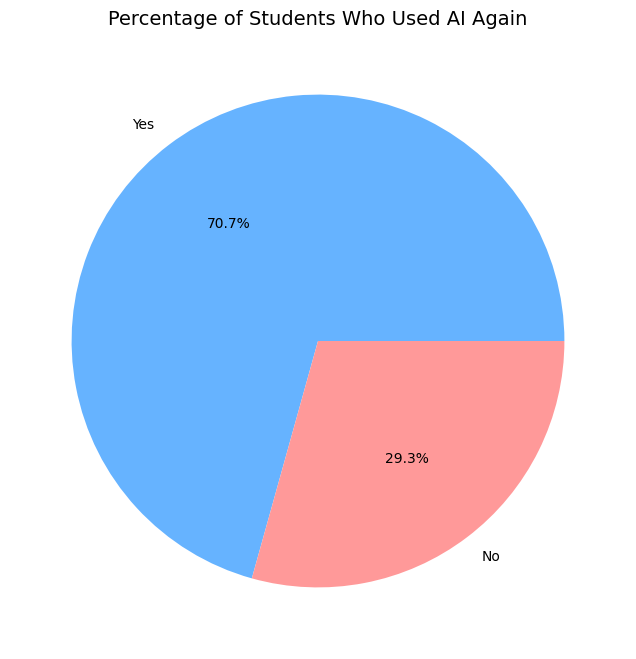

In [58]:

# رسم الرسم البياني الدائري
plt.figure(figsize=(8, 8))
used_again_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['#66b3ff', '#ff9999'],
    labels=['Yes', 'No']  # نستبدل True و False بعناوين أوضح
)
plt.title("Percentage of Students Who Used AI Again", fontsize=14)
plt.ylabel("")
plt.show()


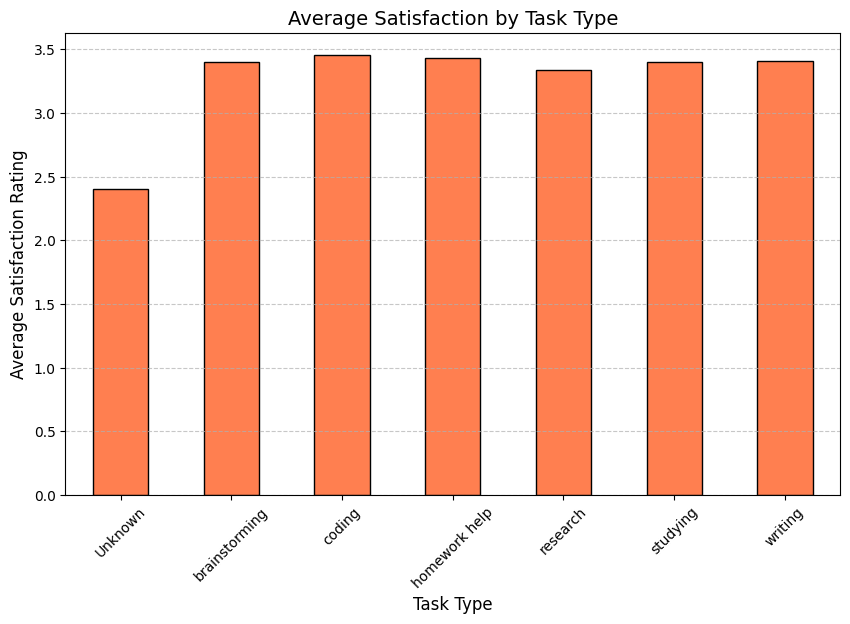

In [59]:
# @title مقارنة متوسط الرضا حسب نوع المهمة
avg_satisfaction_by_task = df.groupby('TaskType')['SatisfactionRating'].mean()

plt.figure(figsize=(10, 6))
avg_satisfaction_by_task.plot(kind='bar', color='coral', edgecolor='black')
plt.title("Average Satisfaction by Task Type", fontsize=14)
plt.xlabel("Task Type", fontsize=12)
plt.ylabel("Average Satisfaction Rating", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [60]:
sessions_by_task = df['TaskType'].value_counts()
sessions_by_task = sessions_by_task.drop('Unknown', errors='ignore')

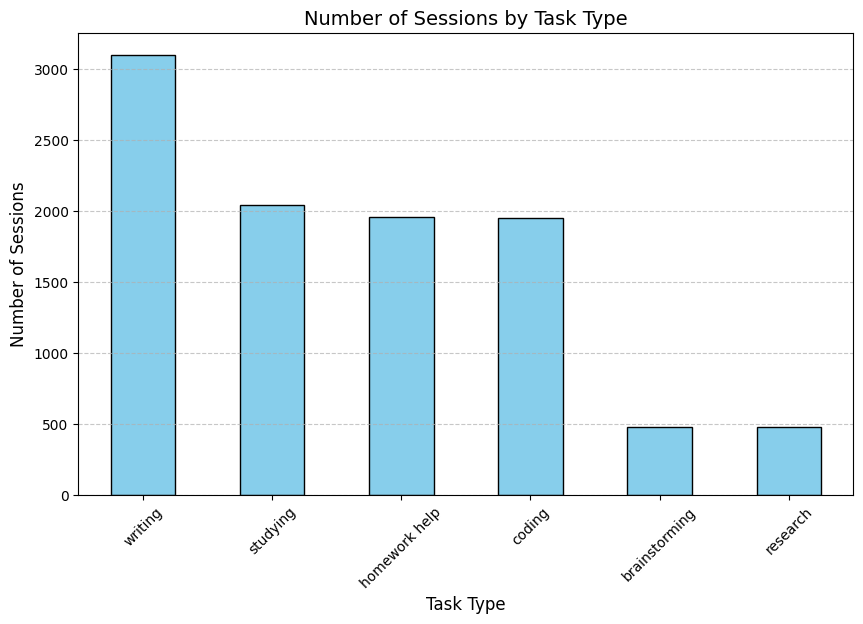

In [61]:
# @title عدد الجلسات حسب نوع المهمة


plt.figure(figsize=(10, 6))
sessions_by_task.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Number of Sessions by Task Type", fontsize=14)
plt.xlabel("Task Type", fontsize=12)
plt.ylabel("Number of Sessions", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [62]:
usage_by_level = df['StudentLevel'].value_counts()

usage_by_level = usage_by_level.drop('Unknown', errors='ignore')

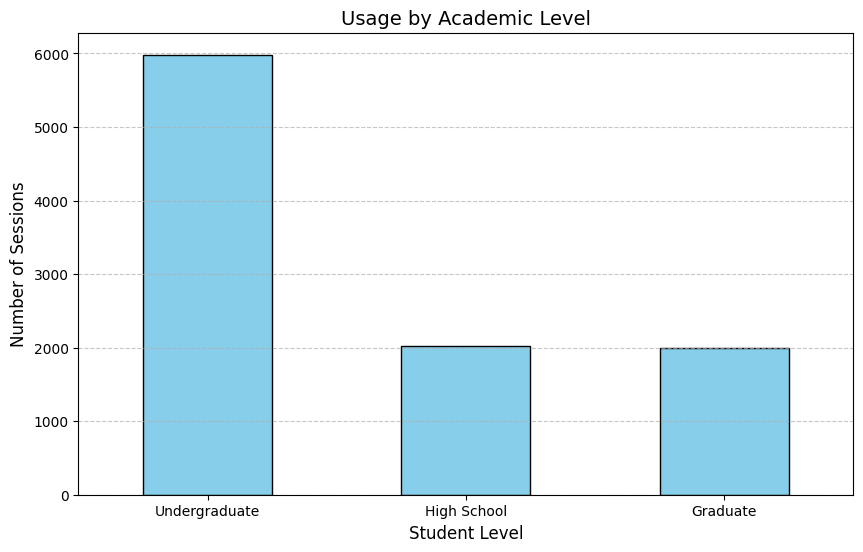

In [63]:
# @title عدد الجلسات حسب المستوى الدراسي
plt.figure(figsize=(10, 6))
usage_by_level.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Usage by Academic Level", fontsize=14)
plt.xlabel("Student Level", fontsize=12)
plt.ylabel("Number of Sessions", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [64]:
df_filtered = df[df['StudentLevel'] != 'Unknown']


أنواع المهام بحسب مستويات الطلاب

In [65]:
grouped = df_filtered.groupby(['StudentLevel', 'TaskType']).size().reset_index(name='Count')


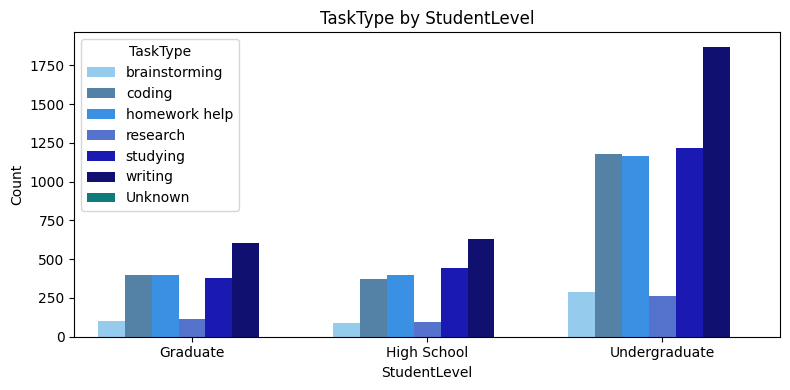

In [66]:
summer_pastels = ['#87CEFA', '#4682B4', '#1E90FF', '#4169E1', '#0000CD', '#000080', '#008B8B']

plt.figure(figsize=(8,4))
sns.barplot(data=grouped, x='StudentLevel', y='Count', hue='TaskType', palette=summer_pastels)
plt.title('TaskType by StudentLevel')
plt.xlabel('StudentLevel')
plt.ylabel('Count')
plt.legend(title='TaskType')
plt.tight_layout()
plt.show()